# Exercise 06

## Some Information about the Evacuation Model

* Agents have a field of vision oriented towards their direction of movement (NORTH, EAST, SOUTH, WEST). Within the field of vision they learn about exits and other humans.

 ![Vision](./resources/FireEvacuation_Refactored_Vision.png) 

* If agents do not see an exit in their field of vision they turn clockwise.
* Agents can cooperate based on their cooperativeness with humans in their field of vision. They choose the nearest visible human that either has speed zero, does not believe in alarm, or does not yet know about any exit. The active agent then tries to reach the agent and
  * makes it believe in alarms
  * exchange information about exits the agent knows
  * sets the speed to 1
* When nervous, agents either slow down or accelerate (accelrate only when `panic_rush` is `True`)
* Introduction of crowds anxiety: When the proportion of agents in the neighbourhood exceeds a threshold, the nervousness increases
* Panic random walk: With certain probability during high nervousness, walk in a random direction

## Evaluation Code


In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import logging
import sys
import itertools
import time
from datetime import timedelta
sys.path.insert(0,'../../abmodel')


from fire_evacuation.model import FireEvacuation, FireEvacuationScenario
from fire_evacuation.agent import Human

In [2]:
uniks = LinearSegmentedColormap.from_list( 'unik', [np.array((80,149,200))/255, np.array((74,172,150))/255,
                                                  np.array((234,195,114))/255, np.array((199,16,92))/255])

def draw_grid(model, ax=None, focus=None):
    """
    Draw the current state of the grid
    """
    if not ax:
        fig, ax = plt.subplots(figsize=(6, 6))

    
    if focus == None:
        focus = (model.grid.width, model.grid.height)

    grid = np.zeros((focus[0], focus[1]))
    for cell in model.grid:
        if cell.coordinate[0] < focus[0] and cell.coordinate[1] < focus[1]:
            for agent in cell.agents:
                if isinstance(agent, Human):    
                    grid[cell.coordinate[0]][cell.coordinate[1]] = 1
                    continue
                
    ax.pcolormesh(grid, cmap=uniks, vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title("Steps: {}".format(model.time))

In [3]:
def run_model(model, steps = [2,2,2,2,2], focus = None):
    """
    Run an experiment with a given model, and plot the results.
    """
    fig = plt.figure(figsize=(12, 5))

    for i in range(0, len(steps)):
        draw_grid(model, fig.add_subplot(2, len(steps) + 1, i + 1 ), focus=focus)
        model.run_for(steps[i])
        
    draw_grid(model, fig.add_subplot(2, len(steps) + 1, i + 2 ), focus=focus)
    
    ax = fig.add_subplot(2, 1, 2)

    d = model.datacollector.get_model_vars_dataframe()
    #d = d.drop(['EscapedEast', 'EscapedSouth', 'EscapedWest', 'EscapedNorth'], axis=1)
    d = d * 100 / len(model.agents)
    d.plot(ax=ax, colormap=uniks, figsize = (12,6))
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Task 2 (Adaptation in the evacuation model)

## Subtask 2.2

**Which decisions are made in the evacuation model by the agents, and how?**

Create a table with the following columns:
1. Decision title
2. Description: What do the agents decide in this decision?
3. Trigger: What triggers the decision?
4. Precondition: Which conditions allow the decision?
5. Influence: What does influence the outcome of the decision? Think of agent and environmental state variables or processes that have an impact on the outcome of the decision (not the impact of the decision on state variables!).

Place your table here or as separate spreadsheet file.

## Subtask 2.3

Extend the model code to count decision, restart the kernel (Menu > Kernel > Restart Kernel and Run All Cells), and inspect results.

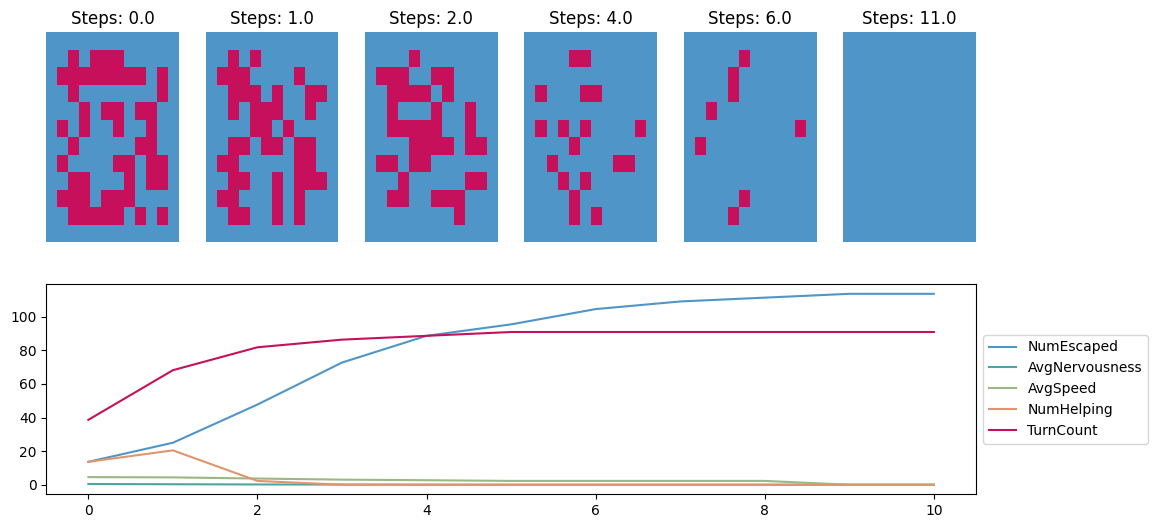

In [4]:
scenario = FireEvacuationScenario(
        random_spawn = True,
        floor_size = 12,
        human_count = 50,
        alarm_believers_prop = 1.0,
        facilitators_percentage = 20,
        panic_rush=False,
        cooperation_mean = 0.3,
        nervousness_mean = 0.3,
        max_steps = 200,
        max_speed = 3,
        seed = 1
)
model = FireEvacuation(scenario)
run_model(model, steps = [1,1,2,2,5])

In [9]:
def batchrun_model(
        scenario,
        experiments,
        replications=20,
        aggregate_output_per_run=True,
    ):
    """
    Instantiates Scenarios for parameter/replication variations, runs the model
    for every Scenario and concats results in a pd.DataFrame.

    Parameters
    ----------
    experiments: pd.DataFrame or dict
        data frame of parameter combinations with parameter names as column names
    replications: int
        number of runs with different RNG
    max_step: int
        the number of steps the model is run in case it does not terminate earlier
    aggregate_output_per_run: bool
        calculate mean values (except for Step)
    """
    # unfortunately, scenario.from_dataframe() is a class method and does not consider values in scenario,
    # so we need to add them to experiments manually:
    experiments = {key: [value] for key, value in scenario.__dict__.items()} | experiments
    
    # create combinations of given parameter values
    if type(experiments) is pd.DataFrame:
        experiments = pd.DataFrame(itertools.product(*[experiments[col] for col in experiments.columns]),
                               columns=experiments.columns)
    elif type(experiments) is dict:
        experiments = pd.DataFrame(itertools.product(*experiments.values()),
                               columns=experiments.keys())
    
    scenarios = scenario.from_dataframe(
            experiments=experiments,
            replications=replications,
    )
    results = pd.DataFrame()
    
    print(f"Perform {len(scenarios)} model runs...")
    start = time.time()
    for scenario in scenarios:
        model =  FireEvacuation(scenario=scenario)
        model.run_model()
        d = model.datacollector.get_model_vars_dataframe()
        d.insert(0, "sid", scenario.scenario_id)
        d.insert(0, "rid", scenario.replication_id)
        d.index.name="Step"
        d = d.reset_index()
        # calc means
        if aggregate_output_per_run:
            d = d.groupby(["sid", "rid"]).agg(
                {column:"mean" if column != "Step" else "max" for column in d.columns}
            )
        d = pd.concat([pd.DataFrame(scenario.__dict__, index=d.index), d], axis=1)
        results = pd.concat([results, d])
    print(f"Done! Took {str(timedelta(seconds=time.time() - start))} h")
    return results

In [ ]:
results_ab = batchrun_model(
    scenario = FireEvacuationScenario(
        random_spawn = True,
        floor_size = 12,
        human_count = 90,
        cooperation_mean=0.3,
        facilitators_percentage = 15,
        panic_rush=False,
        max_speed = 2,
        max_steps = 200,
    ),
    experiments =
        {"alarm_believers_prop": np.arange(0.1,0.8,0.1)},
    replications=10,
    aggregate_output_per_run=True,
)

Perform 70 model runs...


In [ ]:
# implement batch runs here

**Describe your finding here (learn about Markdown syntax via Menu > Help > Markdown Reference)!**

# Task 3 (Exploring the interplay of different objectives in the evacuation model)

## Subtask 3.1

**List the measures suitable to quantify success for each of the two selected objectives here!**

## Subtask 3.2

**Write the objective funtion here (by editing the formula and symbols below)!**

Find hints to write formula in markdown [here](https://jupyterbook.org/en/stable/content/math.html). A comprehensive introduction about how to write math formula in LaTeX is in the [LaTeX wiki](https://en.wikibooks.org/wiki/LaTeX/Mathematics). A list of all mathematical symbols and their LaTeX code is [here](https://artofproblemsolving.com/wiki/index.php/LaTeX:Symbols).
Objective function for <decision>
    
$$u_{option}^i = \sum$$
    
### Meaning of symbols
 * $i$ agent
 * $u$ utility    

# Task 4 (Extend adaptation in the evacuation model)

## Subtask 4.1

**Describe your concept to improve *turn()* and the relevant agent properties here (bullet points)!**

## Subtask 4.2

Implement your improvements to the *turn()* method.

## Subtask 4.3

Restart the kernel to apply your changes in *abmodel/fire_evacuation/agent.py*

In [ ]:
scenario = FireEvacuationScenario(
        random_spawn = True,
        floor_size = 12,
        human_count = 90,
        alarm_believers_prop = 0.3,
        facilitators_percentage = 20,
        panic_rush=False,
        cooperation_mean = 0.3,
        nervousness_mean = 0.3,
        max_steps = 200,
        max_speed = 3,
        seed = 1,
        # switch for turn() version
)
model = FireEvacuation(scenario)
run_model(model, steps = [1,1,2,2,5])

In [ ]:
from scipy import stats

def analyse_significance_predictcrowd(data, title=""):

    print(f"Analysing {title}...")
    
    data = data.groupby(['predictcrowd', "seed"]).agg("mean").reset_index()
    # implement t-test

    # Interpret the results:
    # print appropriate messages about the t-test result, giving the level of significance
        
    data.boxplot(column=['Step'], by='predictcrowd', figsize = (12,6))
    None

Describe your findings here: